<a href="https://colab.research.google.com/github/nanna273/MLEndLS_AB/blob/main/ECS7020P_miniproject_basic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECS7020P mini-project submission - basic  

## MLEndLS London Sounds audio dataset - "indoors or outdoors?"

**Contents:**  
1 Author  
2 Problem formulation  
3 Machine Learning pipeline  
4 Transformation stage  
5 Modelling  
6 Methodology  
7 Dataset  
8 Results  
9 Conclusions

# 1 Author

**Student Name**:  Anna Burlingsby  
**Student ID**:  210900587



# 2 Problem formulation

London is a vibrant city, full of both natural and man-made noises. One can suppose that different areas of London might be audially different from one another, and therefore may be identified as such by recordings taken in those areas. This is likely a complex problem, and therefore a starting point from a machine learning point of view might be to try to distinguish between sounds that were recorded indoors vs. outdoors.  

This notebook will establish a pipeline to identify, from a dataset of short audio recordings taken around London, whether they are indoors or outdoors.

# 3 Machine Learning pipeline

Broadly, the pipeline is divided into the following stages:  
1. Load data, where the raw data is brought into the notebook, and the relevant files are selected.
2. Transformation, where the audio files are processed to extract features.
4. Validation, where models are compared, hyperparamters tuned, and one model is selected.
3. Testing, where the selected model is tested before deployment.
6. Training, where the model is re-trained on the whole dataset.
4. Deployment (not covered in this notebook), where models are deployed on unseen data.  

Below, the libraries that will be used to address this problem are imported.

In [ ]:
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os, sys, re, pickle, glob
import urllib.request
import zipfile

import IPython.display as ipd
from tqdm import tqdm
import librosa
import librosa.display

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


# 4 Transformation stage

## 4.1 Feature extraction  

The audio data available does not have, on its own, appropriate features for machine learning models. In addition, it is presented in the time domain, i.e. a series of amplitudes of sound against the timestamp.  

### 4.1.1 Basic features

Several basic features of each recording are extracted. The input for each of these is the audio recording, and the output is a single feature for each of the below.:  

- Overall power of the recording.
- Mean of the pitch of the recording.
- Standard deviation of the pitch.
- Fraction of the recording that is voiced.  

### 4.1.2 More advanced features  

The time series data can also be converted to the frequency domain with a Fast Fourier Transform (FFT). This presents a series of new audio features that can be extracted by the Python Librosa library. The below will be explored in this notebook. The input to each of them is the fourier transformed spectrum, and the output is a number of features as indicated:  

- Spectral contrast - 6 features
- Chroma - 13 features
- MFCC - 20 features
- RMS - 1 feature
- Spectral centroid - 1 feature
- Spectral bandwidth - 1 feature
- Spectral flatness - 1 feature
- Spectral rolloff - 1 feature.  

Due to the time constraints of producing this notebook, any further description of the meaning of each of the advanced features will not be conducted.  

## 4.2 Feature selection  

The combination of the extracted basic and advanced features will create 48 features in a dataset of 462 samples. While it may be possible to create a model with this many features, the so-called 'curse of dimensionality' means that there is a risk of overfitting, and therefore only a few features should be selected.  

The process of selection features in this notebook is to visualise the data using boxplots, and select the features that show distinction in their distributions between *indoor* and *outdoor* areas. This is conducted in section 7.6.2.  

The input into this stage is the 48 extracted features, and the output is a subset of these features as determined by the visualisation.

# 5 Modelling

The training data will be z-score normalised before the model is applied, using the Python 'Standard Scaler'. The models tend to perform better with scaled data, because of how they calculate distances that are used to create classifiers.

A supervised machine learning problem has been presented in this notebook, as labels are available for the data. Unsupervised methods are likely to be considerably less accurate. The labels are also binary, and therefore, models should be selected that can make binary classifications of samples. The below models meet this criteria, and therefore will be explored in this notebook:
- Support Vector Machines (SVM)
- Logistic Regression
- Random Forest.  

The best performing (see section 6) of these models will then be selected to train the final model.

# 6 Methodology

As the MLEndLS dataset is fairly evenly balanced in terms of indoor and outdoor locations, accuracy is likely to be a fairly good estimator of model performance.

## 6.1 Grid search  

The models from section 5 will have their hyperparameters tuned using grid search.

## 6.2 Cross validation  

Cross-validation with 5 folds will then be used to select the best of the 3 models. The accuracy scores will be compared for each model, and the model with the highest score will be selected.

## 6.3 Model training  

Once the best performing model has been selected, it will be trained on the whole dataset before deployment. The accuracy score will be presented. Confusion matrices will also be presented at this stage to ensure that the data is not being entirely classified as either indoor or outdoor.

# 7 Dataset

## 7.1 Introduction to dataset  

A dataset of audio recordings from around London has been collected by students at Queen Mary University of London (QMUL), and is called MLEndLS. The attributes of this raw data are:  

1. file_id - the name of the file e.g. '0001.wav' that will be used as an index.
2. area - the area of London where the file was recorded e.g. 'british' = The British Museum.
3. spot - the spot in the area where the recording was made e.g. 'street' = Great Russel Street.
4. in_out - whether the spot is 'indoor' or 'outdoor'.
5. Participant - the ID of the student who made the recording e.g. 'S151'.
6. Audio file recording - the .wav file that contains the approximately 7 second clip recorded by the participant.

The following is known about how the data was collected:  

- Participants were given the choice of 6 areas they could make recordings in.
- Each area contained 6 spots.
- Participants selected a minimum of 3 areas, and made recordings in all 6 spots of each of those areas. (note: one area, 'british' has only 5 spots, as the proposed spot 'room23' was inaccessible at the time of the recordings')
- In each area, there are 3 spots that are 'indoor' and 3 spots that are 'outdoor' (apart from for the 'southbank' area, which is 4:2 in favour of outdoor), so there should be roughly equal numbers of each.

## 7.2 Uploading data to notebook  

Below, the filenames are loaded into the notebook and the number of MLEndLS audio files is checked.

In [ ]:
sample_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/*.wav'
files = glob.glob(sample_path)
len(files)

2497

There are 2500 files in the MLEndLS dataset, which has been manually chnaged to 2497 after the removal of 3 files. Two do not contain data (see section 7.3 below), and one is known to be a mislabelled location ('room13').

The attributes of each file have been provided in a .csv file, and are loaded into a dataframe below.

In [ ]:
MLEndLS_df = pd.read_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/MLEndLS.csv').set_index('file_id') 
MLEndLS_df

,area,spot,in_out,Participant
file_id,,,,
0001.wav,british,street,outdoor,S151
0002.wav,kensington,dinosaur,indoor,S127
0003.wav,campus,square,outdoor,S18
0004.wav,kensington,hintze,indoor,S179
0005.wav,campus,square,outdoor,S176
...,...,...,...,...
2496.wav,westend,trafalgar,outdoor,S151
2497.wav,campus,square,outdoor,S6
2498.wav,westend,national,indoor,S96


Summary statistics about the dataframe are presented below.

In [ ]:
MLEndLS_df.describe(include='all')

,area,spot,in_out,Participant
count,2500,2500,2500,2500
unique,6,32,2,176
top,campus,square,outdoor,S28
freq,823,219,1319,18


It is noted that there are 32 unique spots in the dataset, whereas it is known that there are a total of 36. Inspection of the spot names shows that some areas have spots with the same name as others.

## 7.3 Data cleaning ##  

Some of the audio files do not contain any information. Below is some code that will identify these files, by opening them and using the librosa library to calculate the sum of their amplitude. Files with a zero amplitude are removed from the dataset.

In [ ]:
# Code was run once, presented in the notebook for completeness.
# for n, file in enumerate(files):
#   fs = None # Sampling frequency
#   x, fs = librosa.load(files[n], sr=fs)
#   empty_filenames = []
#   if x.sum() == 0:
#     print(file)

Output of above cell:  

```
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/2206.wav  
/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/training/0033.wav
```

The empty files are '2206.wav' and '0033.wav'. These have manually been removed from the Google Drive folder, and the above code will not be run for future executions of this notebook.  

The empty file in the non-existent 'room13' is identified as '0762.wav' below. It has also been manually removed.

In [ ]:
MLEndLS_df.loc[MLEndLS_df.spot=='room13']

,area,spot,in_out,Participant
file_id,,,,
0762.wav,british,room13,indoor,S71


In [ ]:
to_drop = ['2206.wav', '0033.wav', '0762.wav']
MLEndLS_df = MLEndLS_df.drop(to_drop)

### 7.3.1 Data sampling  

There are 2497 files in the dataset, which will take a long time to pre-process. At least for investigation and feature selection, a smaller dataset will be required. For this, there are the following preferences:  
- Roughly equal number of indoor and outdoor locations.
- Full range of spots.  

As the dataset is balanced for indoor and outdoor, both of the above can be achieved by randomly selecting data, but stratified by spots. The total number of files required will be at least 49, as there are 48 features that are being investigated (see section 7.5). As there are 35 unique spots (36 known and 'room23' removed'), the small dataset will have 350 recordings, i.e. 10 from each spot.  

As some spots have the same names as one another, a new feature will be extracted which combines the spot and area names to create a unique identifier for each spot.

In [ ]:
MLEndLS_df['area_spot'] = MLEndLS_df['area'] + MLEndLS_df['spot']
sample_df = MLEndLS_df.groupby(
    'area_spot', group_keys=False).apply(
        lambda x: x.sample(10, random_state=0))
sample_df

,area,spot,in_out,Participant,area_spot
file_id,,,,,
1564.wav,Euston,forecourt,outdoor,S109,Eustonforecourt
1526.wav,Euston,forecourt,outdoor,S176,Eustonforecourt
1733.wav,Euston,forecourt,outdoor,S47,Eustonforecourt
0319.wav,Euston,forecourt,outdoor,S85,Eustonforecourt
0707.wav,Euston,forecourt,outdoor,S46,Eustonforecourt
...,...,...,...,...,...
2209.wav,westend,trafalgar,outdoor,S12,westendtrafalgar
2496.wav,westend,trafalgar,outdoor,S151,westendtrafalgar
0150.wav,westend,trafalgar,outdoor,S11,westendtrafalgar


In [ ]:
sample_files = [file for file in files
                if file.split('/')[-1] in sample_df.index]

## 7.4 Data visualisation  

Below is a code cell that previews one of the audio files.

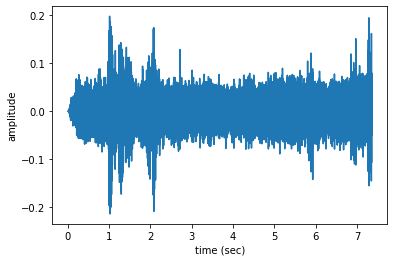

In [ ]:
n = 1
fs = None # Sampling frequency
fs = 22050
x, fs = librosa.load(files[n],sr=fs)
t = np.arange(len(x))/fs
plt.plot(t,x)
plt.xlabel('time (sec)')
plt.ylabel('amplitude')
plt.show()
display(ipd.Audio(files[n]))

According to the instructions, each audio file should contain the participant saying 'this is London' at the start of the recording. This can be seen in the above representative example as the considerably higher peaks early in the audio signal.  

Below, the signal undergoes a Fast Fourier Transform (FFT) to transfrom it into the frequency domain.

Text(0, 0.5, 'Amplitude')

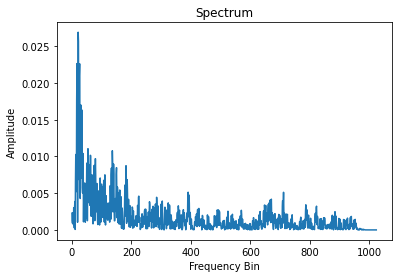

In [ ]:
n_fft = 2048
ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
plt.plot(ft)
plt.title('Spectrum')
plt.xlabel('Frequency Bin')
plt.ylabel('Amplitude')

The FFT can be understood as some characteristic frequency peaks. The actual spectral frequency of each peak is not interpretable from the spectrum (it is an arbitrary scale), but this is not required for this ML classification problem.  

Below is shown the Mel spectrogram of the above audio file. This is described here in this link [https://analyticsindiamag.com/a-tutorial-on-spectral-feature-extraction-for-audio-analytics/].

Text(0.5, 1.0, 'Spectrogram')

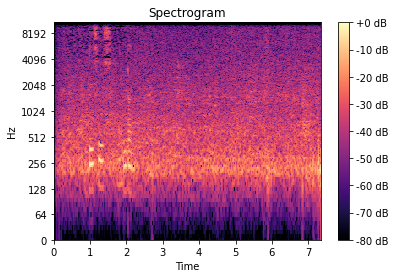

In [ ]:
spec = np.abs(librosa.stft(x, hop_length=512))
spec = librosa.amplitude_to_db(spec, ref=np.max)
librosa.display.specshow(spec, sr=fs, x_axis='time', y_axis='log')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram')

The Mel spectrogram is an image of the data as it appears to human ears. One thing that is clear is that the data is not equivariate, and therefore a convolutional neural network should not be used on the raw data. However, the time domain should not be worked in (the time of sounds is arbitrary), and thus the sound should be transformed to the frequency domain for feature extraction.

## 7.5 Feature extraction  

The features that will be used to predict whether sound was recorded indoors or outdoors are extracted from audio recordings.  

The code to extract the files will **not** execute every time the notebook is run, as it will take over 30 minutes. The extracted features have been saved in '.csv' files on a Google drive in section 7.5.3, which is later re-imported into the notebook in section 7.6.  

### 7.5.1 Basic features  

First, the librosa library is used to extract the pitch, as well as the portions to the recording that contain voices.


In [ ]:
def getPitch(x,fs,winLen=0.02):
  #winLen = 0.02 
  p = winLen*fs
  frame_length = int(2**int(p-1).bit_length())
  hop_length = frame_length//2
  f0, voiced_flag, voiced_probs = librosa.pyin(y=x, fmin=80, fmax=450, sr=fs,
                                                 frame_length=frame_length,hop_length=hop_length)
  return f0,voiced_flag

In [ ]:
def getXy_basic(files,labels_file, scale_audio=False, onlySingleDigit=False):
  X_1, X_2, y =[], [], []
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]
    yi = labels_file.loc[fileID]['in_out']=='indoor'

    fs = None # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)

    # Without scaled audio
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi1 = [power,pitch_mean,pitch_std,voiced_fr]
    X_1.append(xi1)

    # With scaled audio
    x = x/np.max(np.abs(x))
    f0, voiced_flag = getPitch(x,fs,winLen=0.02)
      
    power = np.sum(x**2)/len(x)
    pitch_mean = np.nanmean(f0) if np.mean(np.isnan(f0))<1 else 0
    pitch_std  = np.nanstd(f0) if np.mean(np.isnan(f0))<1 else 0
    voiced_fr = np.mean(voiced_flag)

    xi2 = [power,pitch_mean,pitch_std,voiced_fr]

    X_2.append(xi2)
    y.append(yi)

  return np.array(X_1), np.array(X_2), np.array(y)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# fileID = [file.split('/')[-1] for file in sample_files]

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_1, X_2, y_1 = getXy_basic(sample_files, labels_file=MLEndLS_df, scale_audio=True, onlySingleDigit=True)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_basic_scaled = pd.DataFrame(X_1, index=fileID)
# df_basic_scaled['indoor'] = y_1
# df_basic_scaled = df_basic_scaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})

# df_basic_unscaled = pd.DataFrame(X_2, index=fileID)
# df_basic_unscaled['indoor'] = y_1
# df_basic_unscaled = df_basic_unscaled.rename(
#     columns={0:'power', 1:'pitch_mean', 2:'pitch_std', 3:'voiced_fr'})

### 7.5.2 STFT  

A number of features can be extracted from the data via the librosa library. Due to the time constraints of this project, domain understanding of these will not be sought. Other methods will be used to determine useful potential features for model fitting. The 'librosa.feature' methods give a total of 44 potential features to investigate. The code is run twice, once with, and once without audio scaling. Both will be investigated.

In [ ]:
def getXy_STFT(files,labels_file, scale_audio=False):
  X,y =[],[]
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]
    yi = labels_file.loc[fileID]['in_out']=='indoor'

    fs = 22050 # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)
    if scale_audio: x = x/np.max(np.abs(x))
    n_fft = 2048
    ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
    sc = librosa.feature.spectral_contrast(S=ft, sr=fs) # features 0-6
    ch = librosa.feature.chroma_stft(S=ft, sr=fs) # features 7-19
    mf = librosa.feature.mfcc(S=ft, sr=fs) # features 20-39
    rm = librosa.feature.rms(S=ft) # feature 40
    st = librosa.feature.spectral_centroid(S=ft, sr=fs) # feature 41
    sb = librosa.feature.spectral_bandwidth(S=ft, sr=fs) # features 42
    sf = librosa.feature.spectral_flatness(S=ft) # feature 43
    sr = librosa.feature.spectral_rolloff(S=ft, sr=fs) # feature 44

    features = [sc.T, ch.T, mf.T, rm.T, st.T, sb.T, sf.T, sr.T]

    xi = np.concatenate((features), axis=1)[0]

    X.append(xi)
    y.append(yi)

  return np.array(X),np.array(y)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_3, y_3 = getXy_STFT(sample_files, labels_file=MLEndLS_df, scale_audio=True)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_stft_scaled = pd.DataFrame(X_3,index=fileID)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_4, y_4 = getXy_STFT(sample_files, labels_file=MLEndLS_df, scale_audio=False)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_stft_unscaled = pd.DataFrame(X_4, index=fileID)
# df_stft_unscaled

### 7.5.3 Combining features  

Below the basic and FFT features are combined into 2 dataframes, one with scaled audio and one without. Each of these is saved to a '.csv' file, so that repeated iterations of the notebook will not need to run the functions. The files have been manually renamed in the folder to avoid accidentally writing over them.

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_scaled = pd.concat([df_stft_scaled, df_basic_scaled], axis=1)
# df_scaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features.csv')

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_unscaled = pd.concat([df_stft_unscaled, df_basic_unscaled], axis=1)
# df_unscaled.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features.csv')

## 7.6 Feature selection  

Not all the features will correlate with the target variable. A PCA will be conducted, to attempt to visualise any possible linear separation of the target variable. 

First, the feature data is re-introduced to the notebook.

In [ ]:
scaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/scaled_features_221206.csv'
unscaled_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/unscaled_features_221206.csv'
df_scaled = pd.read_csv(scaled_path, index_col=0)
df_unscaled = pd.read_csv(unscaled_path, index_col=0)

The features extracted from both scaled and unscaled recordings are available at this point. There would be pros and cons to using each for the modelling. On the one hand, scaling the data might information about the amplitude that could be useful. On the other hand, not scaling the data might risk that the amplitude information is an artefact of the specific recording device. On balance, the features generated using unscaled data will be used for modelling.


In [ ]:
df_unscaled

,0,1,2,3,4,5,6,7,8,9,...,39,40,41,42,43,power,pitch_mean,pitch_std,voiced_fr,indoor
1503.wav,18.289397,15.237543,26.024338,20.640903,20.077127,27.870065,17.802817,0.875300,0.855215,0.730589,...,4.417270e-02,1444.584395,2249.650166,0.001895,3143.847656,0.003179,0.000000,0.000000,0.000000,False
1508.wav,12.497625,18.863118,16.237345,22.890847,29.852114,29.061072,21.394292,0.609158,0.840491,0.986404,...,1.713139e-02,1540.491794,2143.702828,0.006723,2734.716797,0.005375,133.282051,23.992064,0.056634,False
1513.wav,16.174040,10.286885,19.172568,20.253705,23.151255,25.196151,47.252196,0.577654,0.636923,0.780812,...,2.266819e-02,2994.924787,2818.476454,0.006823,6136.962891,0.008092,100.760455,16.537061,0.052774,False
1516.wav,27.171028,24.967471,24.425354,25.900981,22.705612,25.111566,26.409309,0.851757,0.838041,1.000000,...,7.648251e-03,1523.228172,1995.570541,0.003564,3003.881836,0.026493,215.337628,21.327012,0.051318,True
1526.wav,28.457784,21.786812,37.443312,19.363316,20.494332,21.036585,44.420024,0.536448,0.781011,0.581308,...,1.034088e-06,2129.247212,2355.296645,0.107004,4392.773438,0.003666,183.366309,19.626663,0.057047,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0448.wav,14.761386,13.682833,27.065507,26.740317,28.324865,22.986969,53.846032,0.778406,0.782058,0.744115,...,2.769628e-03,1145.467231,1687.157563,0.001612,2207.153320,0.007670,156.521517,24.836099,0.112026,False
0455.wav,23.587338,32.317776,23.638037,20.209563,30.214386,24.821376,31.703396,0.279893,0.383710,0.597001,...,9.147807e-02,2338.351992,2807.106942,0.007917,6158.496094,0.009380,126.954456,10.675920,0.066993,False
0481.wav,5.592272,17.960357,19.267577,17.996059,21.742643,22.091406,31.535007,0.565981,0.714612,0.905841,...,6.387549e-09,2758.784397,3145.565548,1.000001,7138.256836,0.020270,131.211895,16.987191,0.193750,False
0482.wav,7.576413,13.056071,20.215105,28.017914,22.399571,26.567440,23.889644,0.558330,1.000000,0.664643,...,3.086124e-02,1422.184777,2292.486189,0.003642,3316.113281,0.007556,147.963728,23.888930,0.104575,True


### 7.6.1 Train test split  

To avoid data leakage, the dataset will be split before any further analysis or feature extraction.

In [ ]:
y = df_unscaled.pop('indoor')

In [ ]:
X = np.array(df_unscaled)

X_train, X_test, y_train, y_test = train_test_split(X,y,
                                                    test_size=0.2,
                                                    random_state=94)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((280, 48), (70, 48), (280,), (70,))

### 7.6.2 Visualisations for feature reductions  

Below are presented some representations of how well each feature correlates with the target variable.

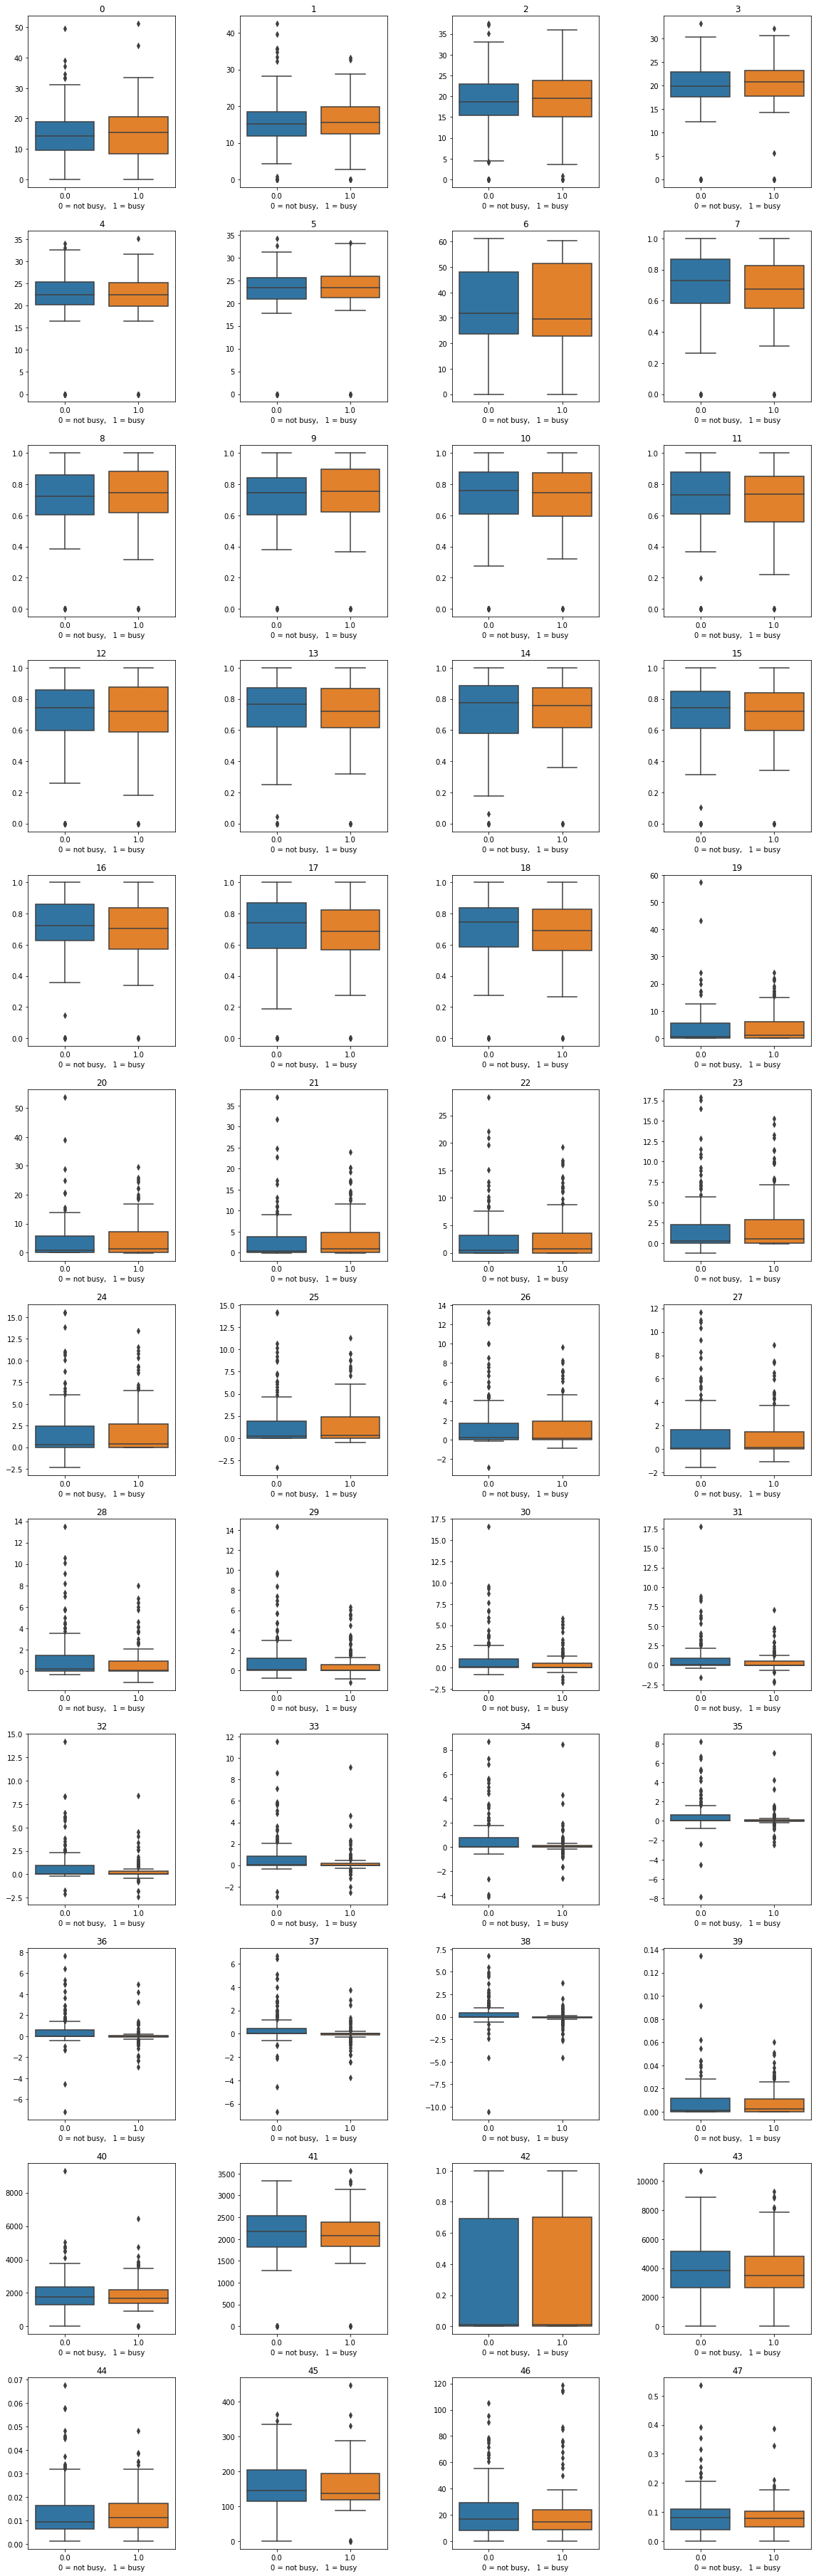

In [ ]:
data = pd.DataFrame(np.column_stack((X_train, y_train)))
data = data.rename(columns={48:'y'})

fig, axs = plt.subplots(12, 4, figsize=(16,50))
fig.tight_layout(w_pad=6, h_pad=4)

for i in range(48):
  ax = axs[i//4, i%4]
  sns.boxplot(data=data, y=i, x='y', ax=ax)
  ax.set_ylabel('')
  ax.set_xlabel('0 = not busy,   1 = busy')
  ax.set_title(i)
plt.show()

And now with the outliers (fliers) hidden.

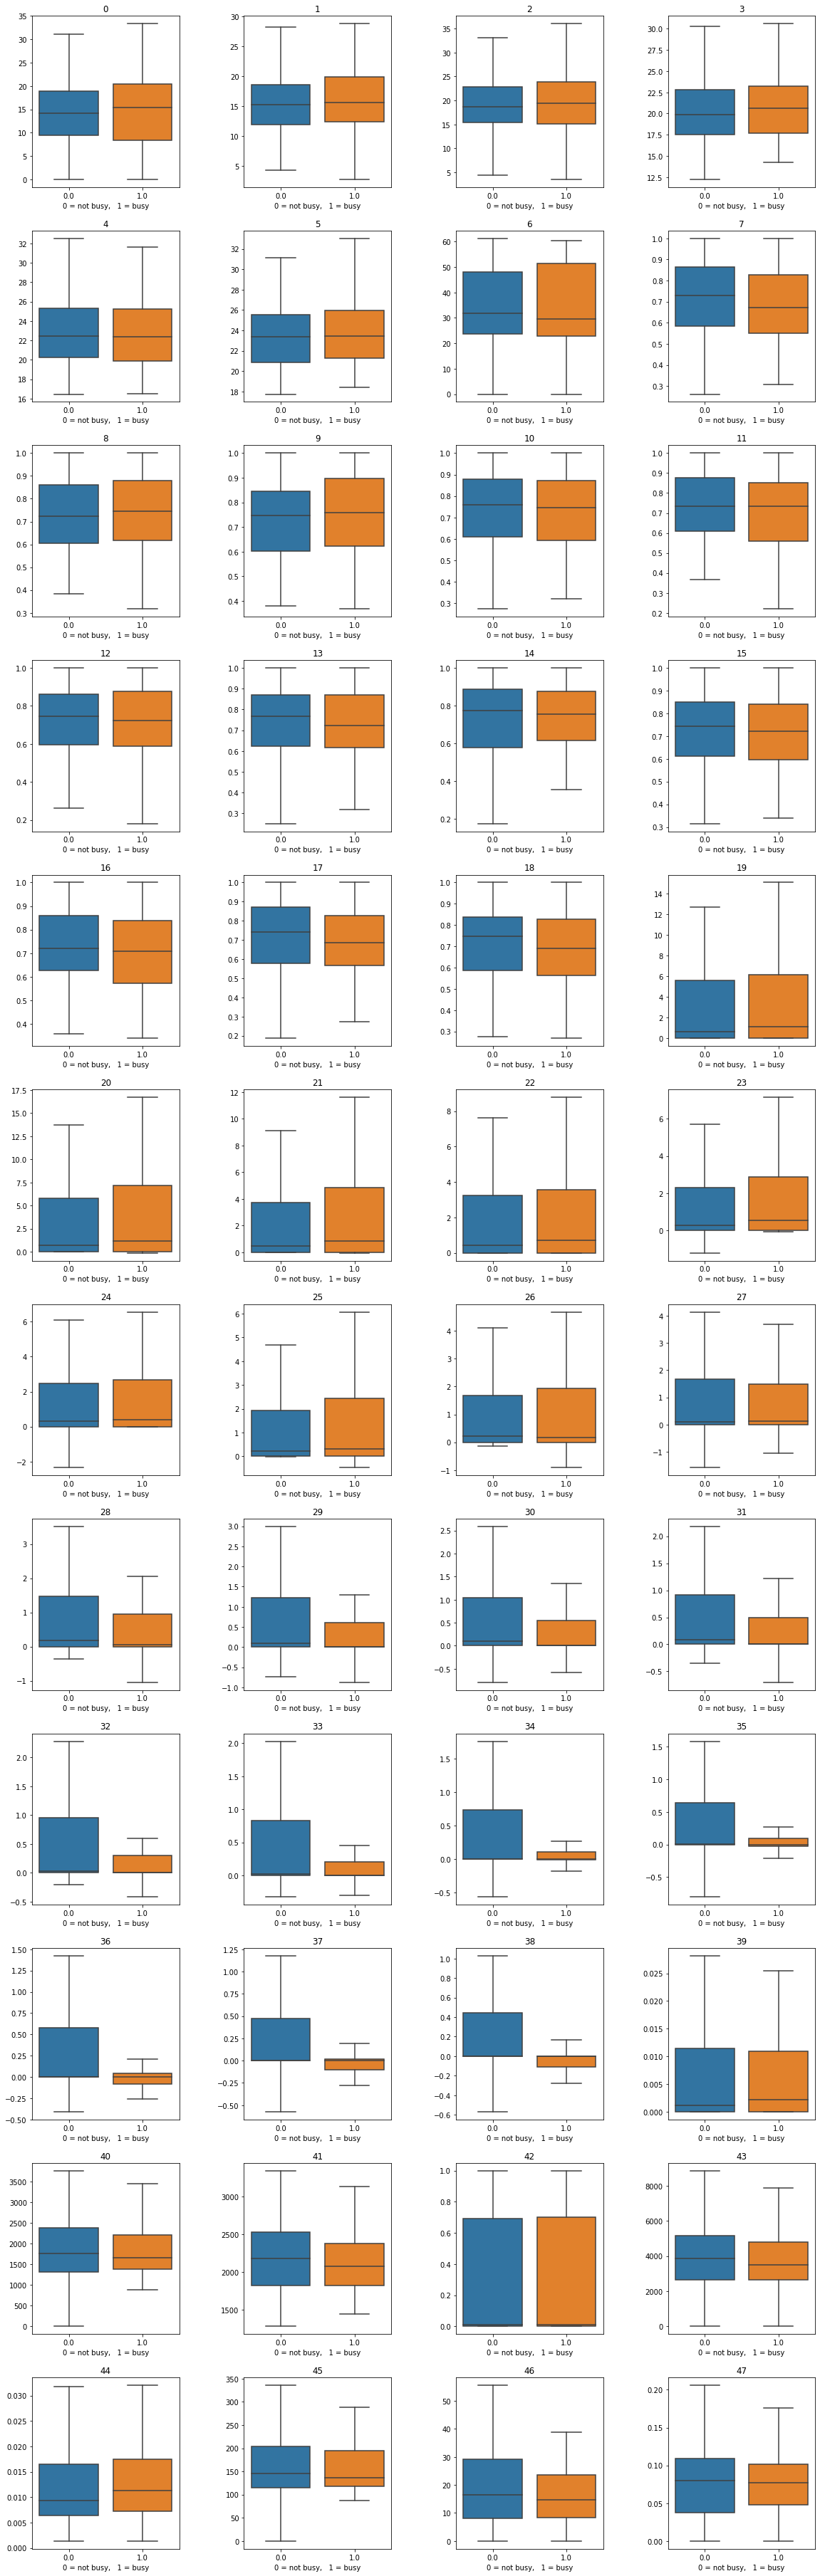

In [ ]:
fig, axs = plt.subplots(12, 4, figsize=(16,50))
fig.tight_layout(w_pad=6, h_pad=4)

for i in range(48):
  ax = axs[i//4, i%4]
  sns.boxplot(data=data, y=i, x='y', ax=ax, showfliers=False)
  ax.set_ylabel('')
  ax.set_xlabel('0 = not busy,   1 = busy')
  ax.set_title(i)
plt.show()

With the fliers hidden, there appears to be some correlation between 34-38 and the target variable (as well as maybe 28-33, but less so). These correspond to 'MFCC' features. Therefore, modelling with only these features will be compared to modelling with all features.

In [ ]:
X_train_1 = X_train[:, 34:39]

## 7.6.2 PCA  

A PCA with 2 components has been conducted on the reduced variables. This will produce a visualisation that is intended to indicate whether this transformation gives good linearly separable variables.

In [ ]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X_train_1)
pca = PCA(n_components=2)
pca = pca.fit(X_scaled)
print(pca.explained_variance_ratio_)
pca = pca.transform(X_scaled)

[0.90839593 0.08101806]


In [ ]:
df_pca = pd.DataFrame(data=pca, columns=['PC1', 'PC2'])

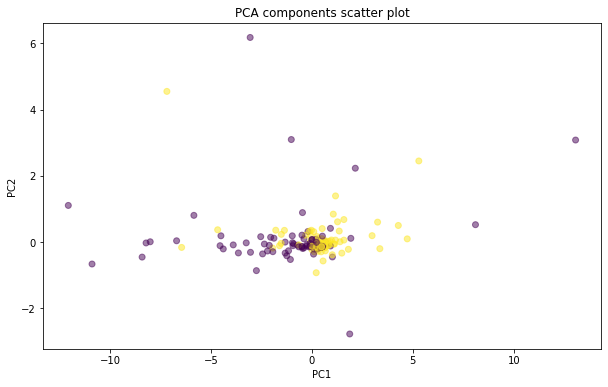

In [ ]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
p = ax.scatter(df_pca.PC1, df_pca.PC2,c=y_train.values, alpha=0.5)
ax.set_title('PCA components scatter plot')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
plt.show()

While there appears to be some separation, the majority of the points are clustered closely together, and therefore the PCA is unlikely to represent good separation for modelling. The two features of the PCA will not be compared with the full set of extracted features, as they are not expected to give better accuracy results.

# 8 Results

## 8.1 Model selection and validation  

### 8.1.1 Grid search to tune hyperparameters  

The best parameters for each model will be selected using sklearn's grid search function. The search will be scored and re-fitted based on accuracy.   

**For the SVM:**

In [ ]:
# defining parameter range
param_grid = {
    'classifier__C': [0.1, 1, 10, 100, 1000],
    'classifier__gamma': [1, 0.1, 0.01, 0.001, 0.0001],
    'classifier__kernel': ['rbf']
    }

pipe = Pipeline(steps = [('scaler', StandardScaler()),
                         ('classifier', svm.SVC())])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=0)

With the subset of features:

In [ ]:
# fitting the model for grid search
grid.fit(X_train_1, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__C': 1000, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=1000, gamma=0.1))])


With the full set of features:

In [ ]:
# fitting the model for grid search
grid.fit(X_train, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__C': 100, 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier', SVC(C=100, gamma=0.1))])


**For the Random Forest:**

In [ ]:
# defining parameter range
param_grid = {
    'classifier__max_depth': [2, 5, 10, 20, 50],
    'classifier__n_estimators': [10, 50, 100, 200, 500]
    }

pipe = Pipeline(steps = [('scaler', StandardScaler()),
                         ('classifier', RandomForestClassifier(
                             class_weight='balanced'))])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=0, cv=3,
                    scoring='balanced_accuracy')
  
# fitting the model for grid search
_ = grid.fit(X_train_1, y_train)

With the subset of features:

In [ ]:
# fitting the model for grid search
grid.fit(X_train_1, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__max_depth': 2, 'classifier__n_estimators': 10}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=2,
                                        n_estimators=10))])


With the full set of features:

In [ ]:
# fitting the model for grid search
grid.fit(X_train, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__max_depth': 50, 'classifier__n_estimators': 50}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=50,
                                        n_estimators=50))])


**For the Logistic Regression:**

In [ ]:
# defining parameter range
param_grid = {
    'classifier__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'classifier__penalty': ['l1', 'l2']
    }

pipe = Pipeline(steps = [('scaler', StandardScaler()),
                         ('classifier', LogisticRegression(
                             solver='liblinear',
                             class_weight='balanced'))])

grid = GridSearchCV(pipe, param_grid, refit=True, verbose=0, cv=3,
                    scoring='balanced_accuracy')
  
# fitting the model for grid search
_ = grid.fit(X_train_1, y_train)

With the subset of features:

In [ ]:
# fitting the model for grid search
grid.fit(X_train_1, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

{'classifier__C': 0.1, 'classifier__penalty': 'l2'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    solver='liblinear'))])


With the full set of features:

In [ ]:
# fitting the model for grid search
grid.fit(X_train, y_train)

# print best parameter after tuning
print(grid.best_params_)
  
# print how our model looks after hyper-parameter tuning
print(grid.best_estimator_)

/usr/local/lib/python3.8/dist-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.8/dist-packages/sklearn/svm/_base.py:1206: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


{'classifier__C': 0.001, 'classifier__penalty': 'l2'}
Pipeline(steps=[('scaler', StandardScaler()),
                ('classifier',
                 LogisticRegression(C=0.001, class_weight='balanced',
                                    solver='liblinear'))])


### 8.1.2 Cross-validation  

Several machine learning models are compared using cross-validation. 5 folds are used for each model 

In [ ]:
# Parameters for cross-validation
cv = 5

**For the subset of 8 features:**

In [ ]:
classifiers = {'SVC' : svm.SVC(
                   C=1000,gamma=0.1),
               'Random Forest' : RandomForestClassifier(
                   max_depth=2, n_estimators=10),
               'Logistic Regression' : LogisticRegression(
                   solver='liblinear', C=0.1, penalty='l2')
               }

print('For the 8 selected variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train_1, y_train, cv=cv)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean():.3f})')

For the 8 selected variables:
The cross-validation scores for SVC are:
[0.625      0.58928571 0.55357143 0.64285714 0.60714286]
(mean = 0.604)
The cross-validation scores for Random Forest are:
[0.67857143 0.55357143 0.66071429 0.64285714 0.66071429]
(mean = 0.639)
The cross-validation scores for Logistic Regression are:
[0.64285714 0.625      0.625      0.625      0.625     ]
(mean = 0.629)


**For the full set of 48 features:**

In [ ]:
classifiers = {'SVC' : svm.SVC(
                   C=100,gamma=0.1),
               'Random Forest' : RandomForestClassifier(
                   max_depth=50, n_estimators=50),
               'Logistic Regression' : LogisticRegression(
                   solver='liblinear', C=0.001, penalty='l2')
               }

print('For the 48 extracted variables:')
for key, clf in classifiers.items():
  pipe = Pipeline(steps = [('scaler', StandardScaler()), ('classifier', clf)])
  scores = cross_val_score(pipe, X_train, y_train, cv=cv)
  print('The cross-validation scores for', key, 'are:')
  print(scores)
  print(f'(mean = {scores.mean():.3f})')

For the 48 extracted variables:
The cross-validation scores for SVC are:
[0.67857143 0.51785714 0.67857143 0.625      0.57142857]
(mean = 0.614)
The cross-validation scores for Random Forest are:
[0.66071429 0.58928571 0.64285714 0.60714286 0.625     ]
(mean = 0.625)
The cross-validation scores for Logistic Regression are:
[0.57142857 0.57142857 0.58928571 0.46428571 0.48214286]
(mean = 0.536)


The Random Forest model, applied to the subset of features, appears to have marginally the best accuracy of around 63 %, and therefore will be tested and subsequently deployed.

## 8.2 Testing  

The selected model (Random Forest) will now be tested against the 20% separated data.

In [ ]:
sc = StandardScaler().fit(X_train_1)
clf = RandomForestClassifier(max_depth=2, n_estimators=100)

X_train_scaled = sc.transform(X_train_1)
clf.fit(X_train_scaled,y_train)

X_test_1 = X_test[:, 34:39]
X_test_scaled = sc.transform(X_test_1)

yt_p = clf.predict(X_train_scaled)
yv_p = clf.predict(X_test_scaled)

In [ ]:
print(f'Training Accuracy {np.mean(yt_p==y_train):.3f}')
print(f'Testing  Accuracy {np.mean(yv_p==y_test):.3f}')
print()
print('The confusion matrix for the training data is:')
print(confusion_matrix(y_train, yt_p))
print()
print('The confusion matrix for the test data is:')
print(confusion_matrix(y_test, yv_p))

Training Accuracy 0.671
Testing  Accuracy 0.600

The confusion matrix for the training data is:
[[134  17]
 [ 75  54]]

The confusion matrix for the test data is:
[[34  5]
 [23  8]]


The testing accuracy of 60 % is relatively low, but according to the confusion matrices, samples are not being exclusively classified one way or the other, and therefore there is some reliability in the model.

## 8.3 Training for deployment  

The time to extract the MFCC feature only is considerably less than all the features extracted in section 7.5. Therefore, below a function is defined to extract only those features. This will be run only once. 

In [ ]:
def get_final(files,labels_file, scale_audio=False):
  X,y =[],[]
  for file in tqdm(files):
    fileID = file.split('/')[-1]
    file_name = file.split('/')[-1]
    yi = labels_file.loc[fileID]['in_out']=='indoor'

    fs = 22050 # if None, fs would be 22050
    x, fs = librosa.load(file,sr=fs)
    if scale_audio: x = x/np.max(np.abs(x))
    n_fft = 2048
    ft = np.abs(librosa.stft(x[:n_fft], hop_length=n_fft+1))
    mf = librosa.feature.mfcc(S=ft, sr=fs)

    xi = mf.T[0][15:20]

    X.append(xi)
    y.append(yi)

  return np.array(X),np.array(y)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# X_f, y_f = get_final(files, labels_file=MLEndLS_df, scale_audio=False)

In [ ]:
# Code was run once, presented in the notebook for completeness.
# fileID = [file.split('/')[-1] for file in files]
# df_final = pd.DataFrame(X_f, index=fileID)
# df_final = pd.DataFrame(X_f, index=fileID)
# df_final['busy'] = y_f
# df_final

In [ ]:
# Code was run once, presented in the notebook for completeness.
# df_final.to_csv('/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/final_features.csv')

In [ ]:
final_path = '/content/drive/MyDrive/MSc AI and Data Science/Data/MLEndLS/final_features_221209.csv'
df_final = pd.read_csv(final_path, index_col=0)
df_final

,0,1,2,3,4,busy
1500.wav,0.758051,0.715227,0.708798,0.684178,0.656829,False
1501.wav,0.005986,0.001342,-0.003359,-0.002329,-0.004107,False
1502.wav,0.000036,0.000025,0.000041,0.000143,0.000154,False
1503.wav,5.629685,5.336440,4.979047,4.743441,4.725907,False
1504.wav,-0.696106,-1.106333,-1.069302,-0.796359,-0.669892,True
...,...,...,...,...,...,...
0494.wav,0.000000,0.000000,0.000000,0.000000,0.000000,False
0495.wav,0.009632,0.004581,0.001805,-0.002443,-0.004263,True
0496.wav,0.782553,0.678824,0.516101,0.525350,0.630753,False
0497.wav,0.002642,-0.001642,-0.010686,-0.017283,-0.020037,False


In [ ]:
y_final = df_final.pop('busy')

Below, the model is trained on the whole dataset, and can be deployed.

In [ ]:
X_f = np.array(df_final)
X_final = StandardScaler().fit_transform(X_f)
model = RandomForestClassifier(max_depth=2, n_estimators=100)
model.fit(X_final, y_final)
y_p = model.predict(X_final)

In [ ]:
print(f'Model Accuracy {np.mean(y_p==y_final):.3f}')
print()
print('The confusion matrix for the data is:')
print(confusion_matrix(y_final, y_p))

Model Accuracy 0.627

The confusion matrix for the data is:
[[1119  198]
 [ 733  447]]


# 9 Conclusions

Your conclusions, improvements, etc should go here  

The classifier seems to be moderately successful at identifying indoor vs. outdoor sounds, with a testing accuracy of 63 %. 

Further areas for development could be:  
- Deeper understanding of extracted features (domain knowledge of sound analysis would be useful here).
- Different classification problems e.g. different areas, clustering participants.
- Improvement of accuracy of classification using the ROC.